# Tutorial 6: NPE vs TSNPE — 4-Parameter Problem
Credit: Tri Nguyen and Claude Code

This notebook compares **NPE** and **TSNPE** (Truncated Sequential NPE) on a hard 4-parameter inference problem.

| Method | Strategy | Proposal | Loss |
|--------|----------|----------|------|
| **NPE** | Train once on the full prior | $p(\theta)$ | Standard NLL |
| **TSNPE** | Train in rounds; truncate prior by posterior density | $p(\theta)\,\mathbf{1}[\log q_{r-1}(\theta\mid x_\mathrm{obs}) > \tau_r]$ | Standard NLL |

## Why TSNPE instead of SNPE-C?

SNPE-C (APT) corrects for the sequential proposal via an atomic contrastive loss, which can become unstable in later rounds. TSNPE (Deistler et al. 2022) takes a different approach:

> **Key idea**: instead of sampling from the previous posterior and correcting, sample from the *prior* but discard any θ whose posterior density is below a threshold τ. The resulting proposal is a *truncated prior* — still a proper distribution — so standard NLL training requires no correction at all.

Benefits:
- No atomic loss needed → simpler, more stable training
- Each round only simulates θ that the previous posterior finds plausible
- The truncation threshold τ is set to accept a fixed target number of samples

## The hard problem: two-component Gaussian inference

We infer **4 parameters** simultaneously:

$$\theta = (\mu_1,\, \log\sigma_1,\, \mu_2,\, \log\sigma_2)$$

- **Prior**: $\mu_1, \mu_2 \sim \mathcal{U}(-5, 5)$,  $\log\sigma_1, \log\sigma_2 \sim \mathcal{U}(-2.5, 1.5)$
- **Simulator**: draw $n=20$ samples from each $\mathcal{N}(\mu_i, \sigma_i^2)$; return $(\bar{x}_1, \log s_1, \bar{x}_2, \log s_2)$
- **Target**: both components in the tails of the prior predictive — only ~0.03% of prior sims land near $x_\mathrm{obs}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner
import torch
import torch.nn as nn
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import norm
from zuko.flows import NSF

np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# Part 0: Simulator and Prior

## Parameters

We infer 4 parameters describing two independent Gaussian components:

$$\theta = (\mu_1,\ \log\sigma_1,\ \mu_2,\ \log\sigma_2)$$

## Simulator

Draw $n = 20$ samples from each component and return summary statistics:

$$x = (\bar{x}_1,\ \log s_1,\ \bar{x}_2,\ \log s_2) \in \mathbb{R}^4$$

In [2]:
# Prior bounds: (mu1, log_sigma1, mu2, log_sigma2)
PRIOR_LOW  = np.array([-5.0, -2.5, -5.0, -2.5])
PRIOR_HIGH = np.array([ 5.0,  1.5,  5.0,  1.5])

N_OBS = 20  # observations per component

# Target observation
# Both components are in the tails of the prior predictive.
# X_OBS = np.array([3.0, 0.5, -2.5, -0.5])
THETA_TRUE = np.array([3.0, 0.5, -2.5, -0.5])  # true params generating x_obs


def sample_prior(n_samples):
    return np.random.uniform(PRIOR_LOW, PRIOR_HIGH, size=(n_samples, 4))


def simulate(theta, n_obs=N_OBS):
    """
    Simulate two-component summary statistics.

    theta: (N, 4) array with columns (mu1, log_sigma1, mu2, log_sigma2)
    Returns x = (xbar1, log_s1, xbar2, log_s2), shape (N, 4).
    """
    mu1 = theta[:, 0]
    sig1 = np.exp(theta[:, 1])
    mu2 = theta[:, 2]
    sig2 = np.exp(theta[:, 3])

    draws1 = np.random.randn(len(theta), n_obs) * sig1[:, None] + mu1[:, None]
    draws2 = np.random.randn(len(theta), n_obs) * sig2[:, None] + mu2[:, None]

    xbar1  = draws1.mean(axis=1)
    log_s1 = np.log(draws1.std(axis=1, ddof=1) + 1e-8)
    xbar2  = draws2.mean(axis=1)
    log_s2 = np.log(draws2.std(axis=1, ddof=1) + 1e-8)

    return np.stack([xbar1, log_s1, xbar2, log_s2], axis=1)

X_OBS = simulate(THETA_TRUE[None, :], n_obs=N_OBS)[0]  # simulate x_obs from true params


print(f"Prior: mu1, mu2 in [{PRIOR_LOW[0]}, {PRIOR_HIGH[0]}]")
print(f"       log_sigma1, log_sigma2 in [{PRIOR_LOW[1]}, {PRIOR_HIGH[1]}]")
print(f"x_obs = {X_OBS}")
print(f"  => component 1: mean={X_OBS[0]:.1f}, std=exp({X_OBS[1]:.1f})={np.exp(X_OBS[1]):.2f}")
print(f"  => component 2: mean={X_OBS[2]:.1f}, std=exp({X_OBS[3]:.1f})={np.exp(X_OBS[3]):.2f}")

Prior: mu1, mu2 in [-5.0, 5.0]
       log_sigma1, log_sigma2 in [-2.5, 1.5]
x_obs = [ 2.71757642  0.45920762 -2.66132206 -0.53248319]
  => component 1: mean=2.7, std=exp(0.5)=1.58
  => component 2: mean=-2.7, std=exp(-0.5)=0.59


## True Posterior (Reference)

Since the two Gaussian components are **independent** given the data, the posterior factors:

$$p(\theta \mid x_\mathrm{obs}) = p(\mu_1, \log\sigma_1 \mid \bar{x}_1, \log s_1) \times p(\mu_2, \log\sigma_2 \mid \bar{x}_2, \log s_2)$$

Each factor uses the same delta-method approximation as Tutorial 6.

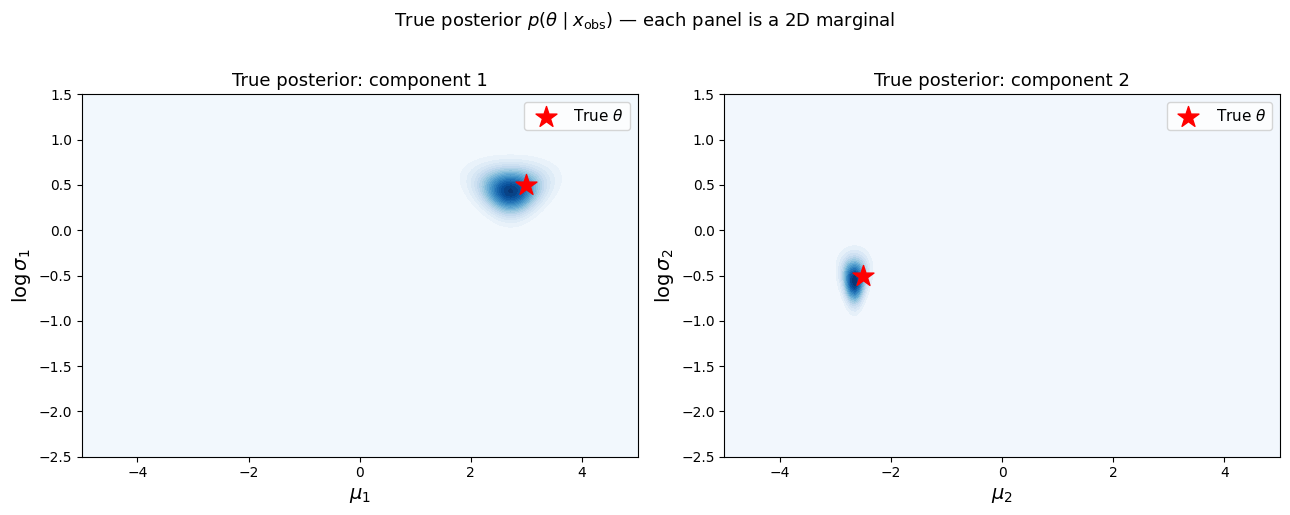

Note how tightly the posterior concentrates relative to the prior range!
  mu1 posterior std ≈ 0.018 vs prior range 10
  log_sigma1 posterior std ≈ 0.016 vs prior range 4


In [3]:
def log_likelihood_approx_2d(mu_grid, logsig_grid, xbar_obs, log_s_obs, n=N_OBS):
    sigma = np.exp(logsig_grid)
    ll_mean = norm.logpdf(xbar_obs, loc=mu_grid, scale=sigma / np.sqrt(n))
    ll_std  = norm.logpdf(log_s_obs, loc=logsig_grid, scale=1.0 / np.sqrt(2 * (n - 1)))
    return ll_mean + ll_std


# Build 2D grids for each pair of marginal parameters
G = 150  # grid resolution

mu1_g = np.linspace(PRIOR_LOW[0], PRIOR_HIGH[0], G)
ls1_g = np.linspace(PRIOR_LOW[1], PRIOR_HIGH[1], G)
mu2_g = np.linspace(PRIOR_LOW[2], PRIOR_HIGH[2], G)
ls2_g = np.linspace(PRIOR_LOW[3], PRIOR_HIGH[3], G)

MU1, LS1 = np.meshgrid(mu1_g, ls1_g)
MU2, LS2 = np.meshgrid(mu2_g, ls2_g)

log_p1 = log_likelihood_approx_2d(
    MU1.ravel(), LS1.ravel(), X_OBS[0], X_OBS[1]
).reshape(G, G)
log_p2 = log_likelihood_approx_2d(
    MU2.ravel(), LS2.ravel(), X_OBS[2], X_OBS[3]
).reshape(G, G)

post2d_c1 = np.exp(log_p1 - log_p1.max())
post2d_c1 /= post2d_c1.sum()

post2d_c2 = np.exp(log_p2 - log_p2.max())
post2d_c2 /= post2d_c2.sum()

# Marginals
marg_mu1 = post2d_c1.sum(axis=0)
marg_ls1 = post2d_c1.sum(axis=1)
marg_mu2 = post2d_c2.sum(axis=0)
marg_ls2 = post2d_c2.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].contourf(MU1, LS1, post2d_c1, levels=20, cmap='Blues')
axes[0].scatter(THETA_TRUE[0], THETA_TRUE[1], s=250, color='red', marker='*',
                zorder=5, label=r'True $\theta$')
axes[0].set_xlabel(r'$\mu_1$', fontsize=14)
axes[0].set_ylabel(r'$\log\sigma_1$', fontsize=14)
axes[0].set_title('True posterior: component 1', fontsize=13)
axes[0].legend(fontsize=11)

axes[1].contourf(MU2, LS2, post2d_c2, levels=20, cmap='Blues')
axes[1].scatter(THETA_TRUE[2], THETA_TRUE[3], s=250, color='red', marker='*',
                zorder=5, label=r'True $\theta$')
axes[1].set_xlabel(r'$\mu_2$', fontsize=14)
axes[1].set_ylabel(r'$\log\sigma_2$', fontsize=14)
axes[1].set_title('True posterior: component 2', fontsize=13)
axes[1].legend(fontsize=11)

plt.suptitle(r'True posterior $p(\theta \mid x_\mathrm{obs})$ — each panel is a 2D marginal',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Note how tightly the posterior concentrates relative to the prior range!")
print(f"  mu1 posterior std ≈ {marg_mu1.std():.3f} vs prior range 10")
print(f"  log_sigma1 posterior std ≈ {marg_ls1.std():.3f} vs prior range 4")

---
# Part 1: Model and Training Functions

We use the same `ConditionalFlow` as before with 4D inputs/outputs. TSNPE always trains with the standard NLL loss — the truncated-prior proposal is a proper distribution, so no atomic correction is needed.

In [4]:
class ConditionalFlow(nn.Module):
    """Conditional normalizing flow for p(theta | x)."""

    def __init__(self, theta_dim=4, x_dim=4, hidden_size=128, embedding_size=32,
                 transforms=8):
        super().__init__()

        self.embedding = nn.Sequential(
            nn.Linear(x_dim, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, embedding_size),
        )

        self.flow = NSF(
            features=theta_dim,
            context=embedding_size,
            transforms=transforms,
            hidden_features=[hidden_size, hidden_size],
        )

    def log_prob(self, theta, x):
        return self.flow(self.embedding(x)).log_prob(theta)

    def sample(self, x, n_samples=1000):
        with torch.no_grad():
            return self.flow(self.embedding(x)).sample((n_samples,)).squeeze(1)


# Pre-compute prior constants
LOG_VOLUME = float(np.sum(np.log(PRIOR_HIGH - PRIOR_LOW)))
PRIOR_LOW_T  = torch.tensor(PRIOR_LOW,  dtype=torch.float32)
PRIOR_HIGH_T = torch.tensor(PRIOR_HIGH, dtype=torch.float32)


def prior_log_prob(theta):
    in_support = torch.all((theta >= PRIOR_LOW_T) & (theta <= PRIOR_HIGH_T), dim=-1)
    return torch.where(
        in_support,
        torch.full((theta.shape[0],), -LOG_VOLUME),
        torch.tensor(float('-inf')),
    )


print("ConditionalFlow defined  (theta_dim=4, x_dim=4, 8 transforms, hidden=128)")

ConditionalFlow defined  (theta_dim=4, x_dim=4, 8 transforms, hidden=128)


In [5]:
def train_npe(model, theta_np, x_np, epochs=100, batch_size=512, lr=5e-4, label=''):
    theta_t = torch.tensor(theta_np, dtype=torch.float32)
    x_t = torch.tensor(x_np, dtype=torch.float32)

    loader = DataLoader(TensorDataset(theta_t, x_t), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    losses = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for theta_b, x_b in loader:
            optimizer.zero_grad()
            loss = -model.log_prob(theta_b, x_b).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        losses.append(epoch_loss / len(loader))
        if (epoch + 1) % 5 == 0:
            print(f"  {label}Epoch {epoch+1:3d}/{epochs}  loss={losses[-1]:.4f}")
    return losses


# TSNPE uses train_npe in every round — no atomic correction needed.
print("train_npe defined (used for both NPE and all TSNPE rounds).")

train_npe defined (used for both NPE and all TSNPE rounds).


In [6]:
N_TOTAL = 5000

theta_npe = sample_prior(N_TOTAL)
x_npe = simulate(theta_npe)

# How many NPE training sims are within distance 1.0 of x_obs?
dist_npe = np.linalg.norm(x_npe - X_OBS, axis=1)
n_near = (dist_npe < 1.0).sum()

print(f"NPE training set: {N_TOTAL} simulations from prior")
print(f"  Sims within distance 1.0 of x_obs: {n_near} / {N_TOTAL}  ({n_near/N_TOTAL*100:.2f}%)")
print(f"  Expected useful signal: extremely limited")

NPE training set: 5000 simulations from prior
  Sims within distance 1.0 of x_obs: 15 / 5000  (0.30%)
  Expected useful signal: extremely limited


In [7]:
npe_model = ConditionalFlow(
    theta_dim=4, x_dim=4, hidden_size=32, embedding_size=16, transforms=4)

npe_losses = train_npe(npe_model, theta_npe, x_npe, epochs=50, label='NPE ')
print("\nNPE training complete")

  NPE Epoch   5/50  loss=9.5240
  NPE Epoch  10/50  loss=6.2187
  NPE Epoch  15/50  loss=3.8410
  NPE Epoch  20/50  loss=2.2734
  NPE Epoch  25/50  loss=1.6445
  NPE Epoch  30/50  loss=1.2614
  NPE Epoch  35/50  loss=1.0187
  NPE Epoch  40/50  loss=0.8754
  NPE Epoch  45/50  loss=0.8073
  NPE Epoch  50/50  loss=0.7927

NPE training complete


In [8]:
x_obs_t = torch.tensor(X_OBS, dtype=torch.float32).unsqueeze(0)  # (1, 4)

npe_samples = npe_model.sample(x_obs_t, n_samples=4000).numpy()  # (4000, 4)

param_names = [r'$\mu_1$', r'$\log\sigma_1$', r'$\mu_2$', r'$\log\sigma_2$']
print("NPE posterior at x_obs:")
for i, name in enumerate(param_names):
    print(f"  {name:>14}: mean={npe_samples[:, i].mean():.3f} "
          f"std={npe_samples[:, i].std():.3f}  "
          f"(true={THETA_TRUE[i]:.1f})")

NPE posterior at x_obs:
         $\mu_1$: mean=2.807 std=0.692  (true=3.0)
  $\log\sigma_1$: mean=0.695 std=0.430  (true=0.5)
         $\mu_2$: mean=-2.819 std=0.616  (true=-2.5)
  $\log\sigma_2$: mean=-0.608 std=0.396  (true=-0.5)


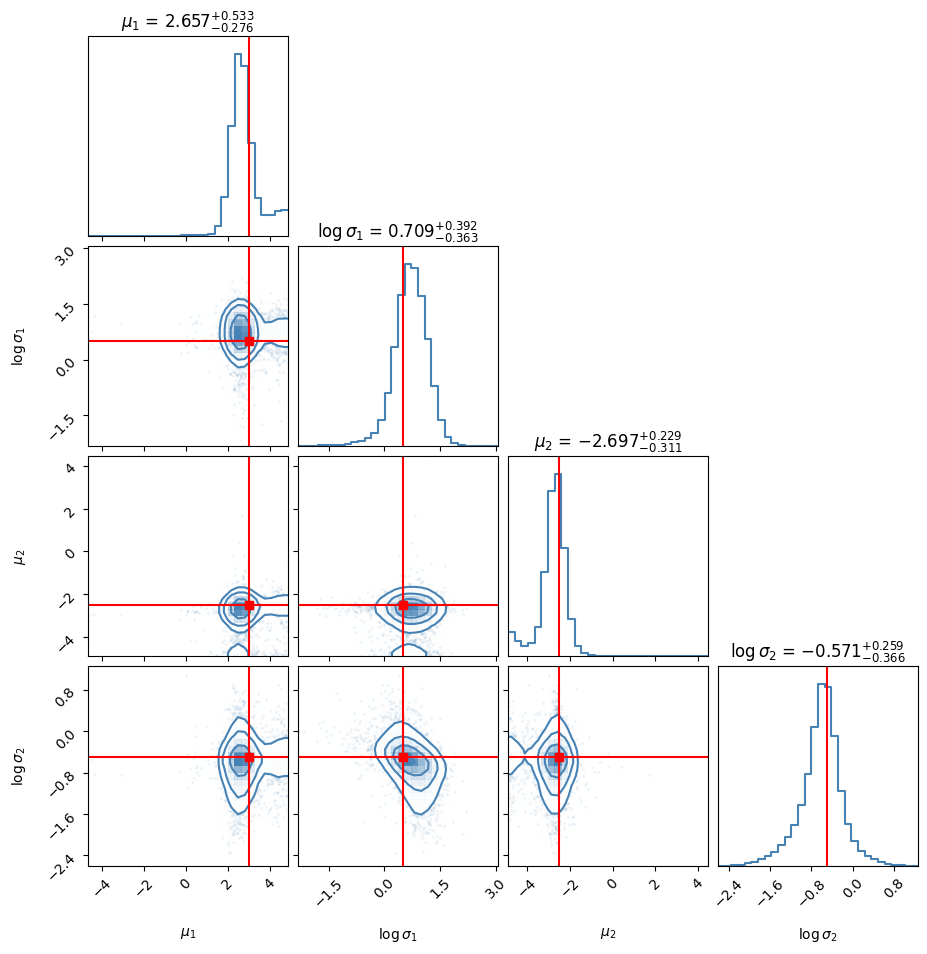

In [9]:
fig = corner.corner(
    npe_samples,
    labels=param_names,
    truths=THETA_TRUE,
    truth_color='red',
    color='steelblue',
    bins=30,
    smooth=1.0,
    smooth1d=1.0,
    show_titles=True,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
)

---
# Part 3: TSNPE — Truncated Sequential Inference

In each round $r > 0$ TSNPE builds a **truncated prior** proposal:

$$q_r(\theta) \propto p(\theta)\,\mathbf{1}\!\left[\log q_{r-1}(\theta \mid x_\mathrm{obs}) \geq \tau_r\right]$$

where $\tau_r$ is chosen so that exactly `N_ROUND_EACH` prior samples survive after filtering.
Because the proposal is still proportional to the prior (just restricted to a region), we can train with the standard NLL — the same `train_npe` function used in round 0.

In [11]:
NUM_ROUNDS = 10
N_ROUND_EACH = int(N_TOTAL / NUM_ROUNDS)
N_OVERSAMPLE = N_ROUND_EACH * 50  # prior candidates to draw before filtering

tsnpe_models = []
tsnpe_losses_all = []
data = []

for round_idx in range(NUM_ROUNDS):
    if round_idx == 0:
        print(f"\nTSNPE Round {round_idx}: {N_ROUND_EACH} samples from prior")
        theta_r = sample_prior(N_ROUND_EACH)
    else:
        # TSNPE: draw from prior, keep only where previous posterior is above threshold
        theta_candidates = sample_prior(N_OVERSAMPLE)
        theta_cands_t = torch.tensor(theta_candidates, dtype=torch.float32)

        with torch.no_grad():
            x_obs_rep = x_obs_t.expand(len(theta_candidates), -1)
            log_q = tsnpe_models[round_idx - 1].log_prob(
                theta_cands_t, x_obs_rep
            ).numpy()

        # threshold: accept exactly N_ROUND_EACH highest-density prior samples
        threshold = np.sort(log_q)[::-1][N_ROUND_EACH - 1]
        mask = log_q >= threshold
        theta_r = theta_candidates[mask][:N_ROUND_EACH]

        acc_rate = mask.mean()
        print(f"\nTSNPE Round {round_idx}:")
        print(f"  Prior candidates:   {N_OVERSAMPLE}")
        print(f"  Log-prob threshold: {threshold:.3f}")
        print(f"  Acceptance rate:    {acc_rate:.4f}  ({acc_rate * 100:.2f}%)")

    x_r = simulate(theta_r)
    data.append((theta_r, x_r))

    if round_idx > 0:
        dist_prev = np.linalg.norm(data[round_idx - 1][1] - X_OBS, axis=1)
        dist_curr = np.linalg.norm(x_r - X_OBS, axis=1)
        print(f"  Median dist to x_obs:  round {round_idx-1}={np.median(dist_prev):.3f}"
              f"  ->  round {round_idx}={np.median(dist_curr):.3f}")

    tsnpe_r = ConditionalFlow(
        theta_dim=4, x_dim=4, hidden_size=32, embedding_size=16, transforms=4)
    if round_idx > 0:
        tsnpe_r.load_state_dict(tsnpe_models[round_idx - 1].state_dict())

    print(f"Training TSNPE Round {round_idx} with standard NLL...")
    tsnpe_r_losses = train_npe(tsnpe_r, theta_r, x_r, epochs=50, label=f'R{round_idx} ')

    tsnpe_models.append(tsnpe_r)
    tsnpe_losses_all.append(tsnpe_r_losses)
    print(f"TSNPE Round {round_idx} complete")


TSNPE Round 0: 500 samples from prior
Training TSNPE Round 0 with standard NLL...
  R0 Epoch   5/50  loss=13.1000
  R0 Epoch  10/50  loss=12.6242
  R0 Epoch  15/50  loss=12.2112
  R0 Epoch  20/50  loss=11.8676
  R0 Epoch  25/50  loss=11.5992
  R0 Epoch  30/50  loss=11.4019
  R0 Epoch  35/50  loss=11.2677
  R0 Epoch  40/50  loss=11.1893
  R0 Epoch  45/50  loss=11.1550
  R0 Epoch  50/50  loss=11.1475
TSNPE Round 0 complete

TSNPE Round 1:
  Prior candidates:   25000
  Log-prob threshold: -5.174
  Acceptance rate:    0.0200  (2.00%)
  Median dist to x_obs:  round 0=5.564  ->  round 1=4.004
Training TSNPE Round 1 with standard NLL...
  R1 Epoch   5/50  loss=4.6978
  R1 Epoch  10/50  loss=4.5565
  R1 Epoch  15/50  loss=4.4466
  R1 Epoch  20/50  loss=4.3571
  R1 Epoch  25/50  loss=4.2870
  R1 Epoch  30/50  loss=4.2345
  R1 Epoch  35/50  loss=4.1979
  R1 Epoch  40/50  loss=4.1762
  R1 Epoch  45/50  loss=4.1666
  R1 Epoch  50/50  loss=4.1645
TSNPE Round 1 complete

TSNPE Round 2:
  Prior cand

In [12]:
# Collect posterior samples from each TSNPE round
tsnpe_samples = [
    tsnpe_models[r].sample(x_obs_t, n_samples=4000).numpy()
    for r in range(NUM_ROUNDS)
]
tsnpe_final_samples = tsnpe_samples[-1]  # (4000, 4)

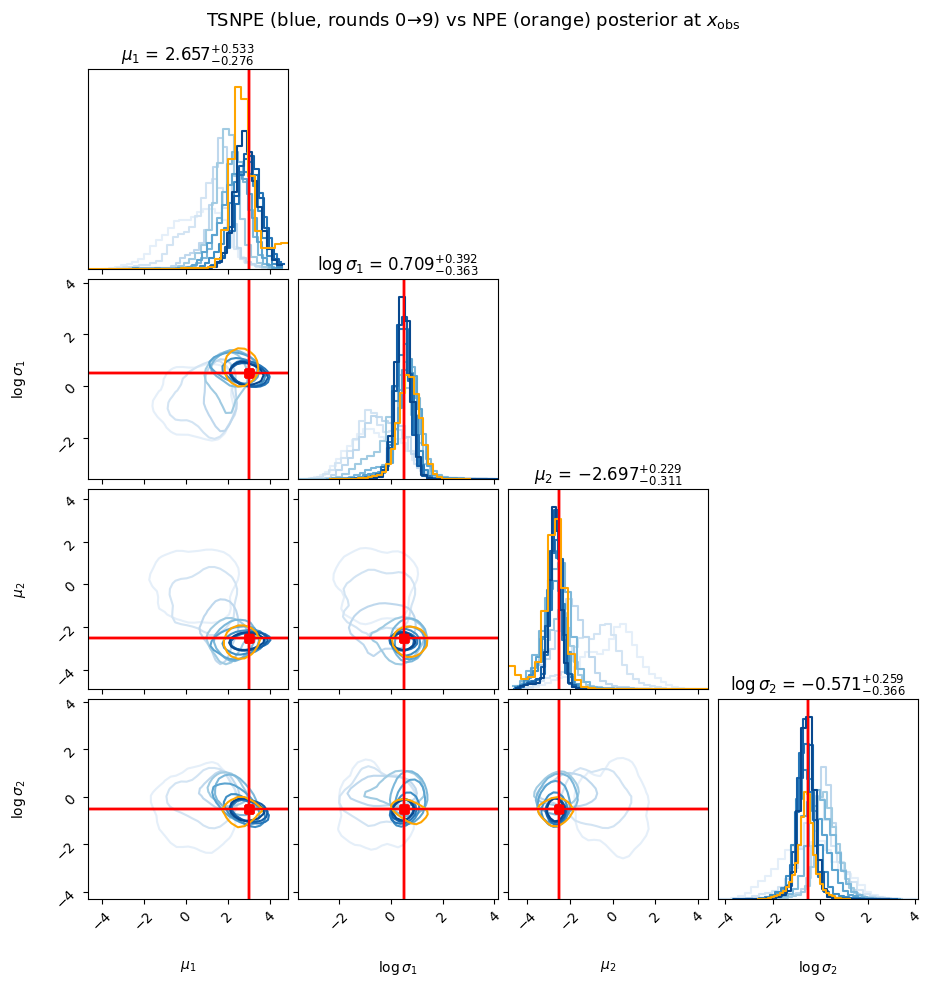

In [13]:
def make_corner_kwargs(color, **extra):
    """Build corner kwargs with explicit contour/hist color overrides."""
    import matplotlib.colors as mcolors
    rgba = mcolors.to_rgba(color)
    return dict(
        labels=param_names,
        truths=THETA_TRUE,
        truth_color="red",
        bins=30,
        smooth=1.0,
        smooth1d=1.0,
        levels=[0.68],
        plot_density=False,
        plot_datapoints=False,
        show_titles=True,
        title_fmt=".3f",
        title_kwargs={"fontsize": 12},
        hist_kwargs={"color": rgba},
        contour_kwargs={"colors": [rgba]},
        contourf_kwargs={"colors": [rgba]},
        **extra,
    )

color_schemes = sns.color_palette("Blues", n_colors=NUM_ROUNDS)

fig = None
for round_idx in range(NUM_ROUNDS):
    fig = corner.corner(
        tsnpe_samples[round_idx],
        fig=fig,
        **make_corner_kwargs(color_schemes[round_idx]),
    )

fig = corner.corner(
    npe_samples,
    fig=fig,
    **make_corner_kwargs("orange"),
)

plt.suptitle(
    r"TSNPE (blue, rounds 0→9) vs NPE (orange) posterior at $x_{\rm obs}$",
    fontsize=13,
    y=1.02,
)
plt.show()

---
# Part 4: Quantitative Metrics

Beyond corner plots, three complementary metrics quantify how well each approximate posterior matches the true posterior:

| Metric | What it measures |
|--------|------------------|
| **Log p(θ_true)** | Density at the ground-truth parameters — single number per model |
| **Z-score** | Per-parameter bias in units of posterior std |
| **Marginal KL** | Shape mismatch vs analytic 1D marginals (exploits the grid we computed above) |
| **C2ST AUC** | Full joint distribution mismatch — 0.5 = perfect, 1.0 = completely wrong |

## Metric 1: Log-probability of θ_true

A quick sanity check: how much probability mass does each approximate posterior place at the true parameter value?

In [14]:
theta_true_t = torch.tensor(THETA_TRUE, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    log_p_npe = npe_model.log_prob(theta_true_t, x_obs_t).item()
    log_p_tsnpe_rounds = [
        m.log_prob(theta_true_t, x_obs_t).item() for m in tsnpe_models
    ]

print("log p(theta_true | x_obs):")
print(f"  NPE:              {log_p_npe:+.3f}")
for r, lp in enumerate(log_p_tsnpe_rounds):
    print(f"  TSNPE round {r:2d}:   {lp:+.3f}")

log p(theta_true | x_obs):
  NPE:              +0.072
  TSNPE round  0:   -8.659
  TSNPE round  1:   -8.006
  TSNPE round  2:   -7.922
  TSNPE round  3:   -5.397
  TSNPE round  4:   -1.013
  TSNPE round  5:   -0.597
  TSNPE round  6:   +0.642
  TSNPE round  7:   +1.395
  TSNPE round  8:   +1.359
  TSNPE round  9:   +1.270


## Metric 2: Z-score per parameter

Measures bias in units of posterior standard deviation. Values near 0 indicate the posterior is centered on the truth; large |z| signals the posterior has shifted away.

In [15]:
print(f"{'Parameter':>14}  {'NPE z':>8}  {'TSNPE z':>8}")
print("-" * 38)
for i, name in enumerate(param_names):
    z_npe = (THETA_TRUE[i] - npe_samples[:, i].mean()) / npe_samples[:, i].std()
    z_tsnpe = (THETA_TRUE[i] - tsnpe_final_samples[:, i].mean()) / tsnpe_final_samples[:, i].std()
    print(f"{name:>14}  {z_npe:+8.2f}  {z_tsnpe:+8.2f}")

     Parameter     NPE z   TSNPE z
--------------------------------------
       $\mu_1$     +0.28     +0.22
$\log\sigma_1$     -0.45     +0.05
       $\mu_2$     +0.52     +0.69
$\log\sigma_2$     +0.27     +0.19


## Metric 3: Marginal KL divergence vs analytic posterior

Compares the shape of each 1D marginal against the analytic posterior computed on the grid above. KL(true ‖ approx) penalises regions where the approximation assigns too little mass.

In [16]:
from scipy.stats import gaussian_kde
from scipy.special import rel_entr

def marginal_kl(samples_1d, analytic_grid, analytic_prob):
    kde = gaussian_kde(samples_1d, bw_method='scott')
    q = kde(analytic_grid)
    q /= q.sum()
    p = analytic_prob / analytic_prob.sum()
    return float(np.sum(rel_entr(p + 1e-10, q + 1e-10)))

grids = [mu1_g, ls1_g, mu2_g, ls2_g]
analytic_marginals = [marg_mu1, marg_ls1, marg_mu2, marg_ls2]

print(f"{'Parameter':>14}  {'KL NPE':>8}  {'KL TSNPE':>9}")
print("-" * 40)
for i, (g, a, name) in enumerate(zip(grids, analytic_marginals, param_names)):
    kl_npe = marginal_kl(npe_samples[:, i], g, a)
    kl_tsnpe = marginal_kl(tsnpe_final_samples[:, i], g, a)
    print(f"{name:>14}  {kl_npe:8.4f}  {kl_tsnpe:9.4f}")
print("\n(Lower is better; 0 = perfect match to analytic posterior)")

     Parameter    KL NPE   KL TSNPE
----------------------------------------
       $\mu_1$    0.1693     0.1227
$\log\sigma_1$    0.6767     0.0357
       $\mu_2$    0.3715     0.0976
$\log\sigma_2$    0.2907     0.0515

(Lower is better; 0 = perfect match to analytic posterior)


## Metric 4: C2ST — Classifier Two-Sample Test

The gold standard in SBI evaluation. We sample from the analytic factored posterior, then train a small MLP to distinguish those samples from the approximate posterior. AUC = 0.5 means the two distributions are indistinguishable (perfect); AUC = 1.0 means they are completely separated (very wrong).

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


def sample_analytic_posterior(n=4000, rng=None):
    """Sample from the factored analytic posterior via grid-CDF inversion."""
    if rng is None:
        rng = np.random.default_rng(0)

    def sample_2d_grid(g1, g2, prob2d, n):
        flat = prob2d.ravel()
        flat = flat / flat.sum()
        idx = rng.choice(len(flat), size=n, p=flat)
        i2, i1 = np.unravel_index(idx, prob2d.shape)
        return g1[i1], g2[i2]

    mu1_s, ls1_s = sample_2d_grid(mu1_g, ls1_g, post2d_c1, n)
    mu2_s, ls2_s = sample_2d_grid(mu2_g, ls2_g, post2d_c2, n)
    return np.stack([mu1_s, ls1_s, mu2_s, ls2_s], axis=1)


def c2st_auc(approx_samples, ref_samples):
    n = min(len(approx_samples), len(ref_samples))
    X = np.vstack([approx_samples[:n], ref_samples[:n]])
    y = np.array([0] * n + [1] * n)
    clf = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=500, random_state=42),
    )
    return cross_val_score(clf, X, y, cv=5, scoring='roc_auc').mean()


ref_samples = sample_analytic_posterior(4000)

auc_npe = c2st_auc(npe_samples, ref_samples)
auc_tsnpe = c2st_auc(tsnpe_final_samples, ref_samples)

print("C2ST AUC (0.5 = perfect, 1.0 = completely wrong):")
print(f"  NPE:    {auc_npe:.3f}")
print(f"  TSNPE:  {auc_tsnpe:.3f}")

C2ST AUC (0.5 = perfect, 1.0 = completely wrong):
  NPE:    0.908
  TSNPE:  0.759


## Summary

All four metrics should tell the same story: TSNPE concentrates simulations near $x_\mathrm{obs}$ by filtering prior samples through the previous round's posterior, learning a sharper and more accurate posterior — while still using the simple standard NLL loss. NPE, trained only on prior samples, produces a posterior that is too broad and often off-center.